# Building Footprint Extraction for the USA

[![image](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/opengeos/geoai/blob/main/docs/examples/building_footprints_usa.ipynb)

## Install package
To use the `geoai-py` package, ensure it is installed in your environment. Uncomment the command below if needed.

In [1]:
#%pip install geoai-py

## Import libraries

In [2]:
import geoai

## Download sample data

In [3]:
raster_url = (
    "https://huggingface.co/datasets/giswqs/geospatial/resolve/main/naip_train.tif"
)
vector_url = "https://huggingface.co/datasets/giswqs/geospatial/resolve/main/naip_train_buildings.geojson"

In [4]:
raster_path = geoai.download_file(raster_url)

File already exists: naip_train.tif


In [5]:
vector_path = geoai.download_file(vector_url)

File already exists: naip_train_buildings.geojson


## Initialize building footprint extraction pretrained model

In [7]:
# Specify the path to the locally downloaded model
model_path = "building_footprints_usa.pth"
extractor = geoai.BuildingFootprintExtractor(model_path=model_path)

Model loaded successfully


## Extract building footprints

### Option 1: Extract building footprints as raster

In [8]:
mask_path = extractor.save_masks_as_geotiff(
    raster_path=raster_path,
    output_path="building_masks.tif",
    confidence_threshold=0.5,
    mask_threshold=0.5,
)

Processing masks with parameters:
- Confidence threshold: 0.5
- Chip size: (512, 512)
- Mask threshold: 0.5
Dataset initialized with 3 rows and 7 columns of chips
Image dimensions: 2503 x 1126 pixels
Chip size: 512 x 512 pixels
Overlap: 25.0% (stride_x=384, stride_y=384)
CRS: EPSG:26911
Processing raster with 6 batches


100%|██████████| 6/6 [00:02<00:00,  2.40it/s]

Object masks saved to building_masks.tif


Convert raster to vector

In [9]:
gdf = extractor.masks_to_vector(
    mask_path=mask_path,
    output_path="building_masks.geojson",
    simplify_tolerance=1.0,
)

Converting mask to GeoJSON with parameters:
- Mask threshold: 0.5
- Min object area: 100
- Max object area: None
- Simplify tolerance: 1.0
- NMS IoU threshold: 0.5
- Regularize objects: True
- Angle threshold: 15° from 90°
- Rectangularity threshold: 70.0%
Mask dimensions: (1126, 2503)
Mask value range: 0 to 255
Found 696 potential objects


100%|██████████| 696/696 [00:00<00:00, 1085.39it/s]


Created 664 valid polygons
Object count after NMS filtering: 664
Regularizing 664 objects...
- Angle threshold: 15° from 90°
- Min orthogonality: 30.0% of angles
- Min rectangularity: 70.0% of bounding box area


100%|██████████| 664/664 [00:00<00:00, 2054.06it/s]

Regularization completed:
- Total objects: 664
- Rectangular objects: 660 (99.4%)
- Other regularized objects: 0 (0.0%)
- Unmodified objects: 4 (0.6%)
Saved 664 objects to building_masks.geojson


### Option 2: Extract building footprints as vector

In [10]:
output_path = "naip_buildings.geojson"
gdf = extractor.process_raster(
    raster_path,
    output_path="buildings.geojson",
    batch_size=4,
    confidence_threshold=0.5,
    overlap=0.25,
    nms_iou_threshold=0.5,
    min_object_area=100,
    max_object_area=None,
    mask_threshold=0.5,
    simplify_tolerance=1.0,
)

Processing with parameters:
- Confidence threshold: 0.5
- Tile overlap: 0.25
- Chip size: (512, 512)
- NMS IoU threshold: 0.5
- Mask threshold: 0.5
- Min object area: 100
- Max object area: None
- Simplify tolerance: 1.0
- Filter edge objects: True
- Edge buffer size: 20 pixels
Dataset initialized with 3 rows and 7 columns of chips
Image dimensions: 2503 x 1126 pixels
Chip size: 512 x 512 pixels
Overlap: 25.0% (stride_x=384, stride_y=384)
CRS: EPSG:26911
Processing raster with 6 batches


100%|██████████| 6/6 [00:03<00:00,  1.68it/s]


Objects before filtering: 749
Objects after filtering: 749
Saved 749 objects to buildings.geojson


## Regularize building footprints

In [11]:
gdf_regularized = extractor.regularize_buildings(
    gdf=gdf,
    min_area=100,
    angle_threshold=15,
    orthogonality_threshold=0.3,
    rectangularity_threshold=0.7,
)

Regularizing 749 objects...
- Angle threshold: 15° from 90°
- Min orthogonality: 30.0% of angles
- Min rectangularity: 70.0% of bounding box area


100%|██████████| 749/749 [00:00<00:00, 2225.37it/s]

Regularization completed:
- Total objects: 749
- Rectangular objects: 695 (92.8%)
- Other regularized objects: 0 (0.0%)
- Unmodified objects: 54 (7.2%)


## Visualize building footprints

In [12]:
gdf.head()

,geometry,confidence,class
549,"POLYGON ((455272.2 5277763.2, 455271 5277762, ...",0.999945,1
1236,"POLYGON ((455984.4 5277643.8, 455983.8 5277643...",0.999941,1
889,"POLYGON ((456074.4 5277719.4, 456073.2 5277718...",0.999941,1
550,"POLYGON ((455243.4 5277855, 455242.8 5277854.4...",0.999938,1
439,"POLYGON ((454989 5277799.2, 454988.4 5277798.6...",0.999931,1


In [14]:
geoai.view_vector_interactive(
    gdf, column="confidence", layer_name="Building", tiles="Satellite"
)

In [15]:
geoai.view_vector_interactive(
    gdf, column="confidence", layer_name="Building", tiles=raster_url
)

In [16]:
geoai.view_vector_interactive(
    gdf_regularized, column="confidence", layer_name="Building", tiles=raster_url
)

Using confidence values (range: 0.57 - 1.00)
Visualization saved to naip_buildings.png
Sample visualization saved to naip_buildings_sample.png


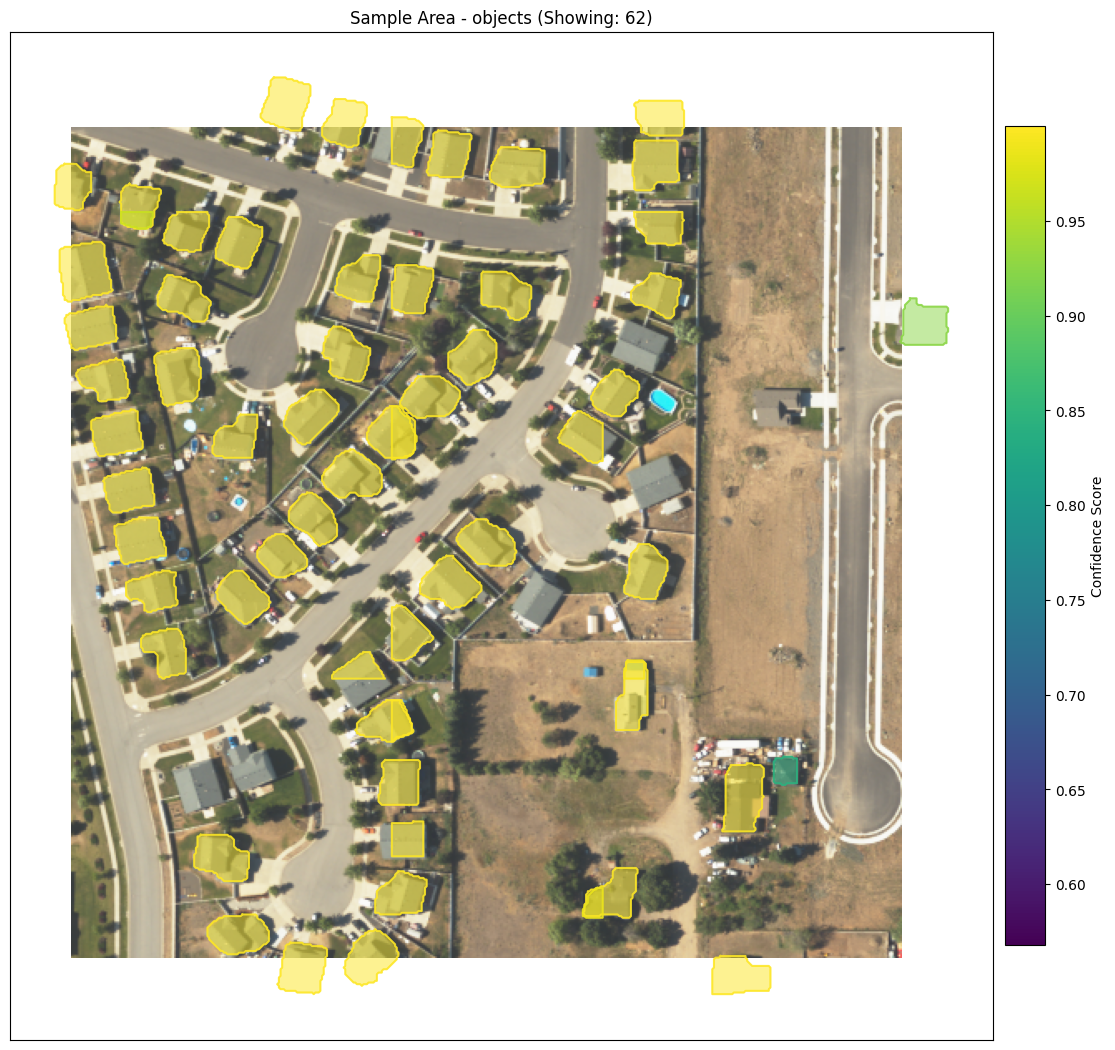

In [17]:
extractor.visualize_results(raster_path, gdf, output_path="naip_buildings.png")

Using confidence values (range: 0.57 - 1.00)
Visualization saved to naip_buildings_regularized.png
Sample visualization saved to naip_buildings_regularized_sample.png


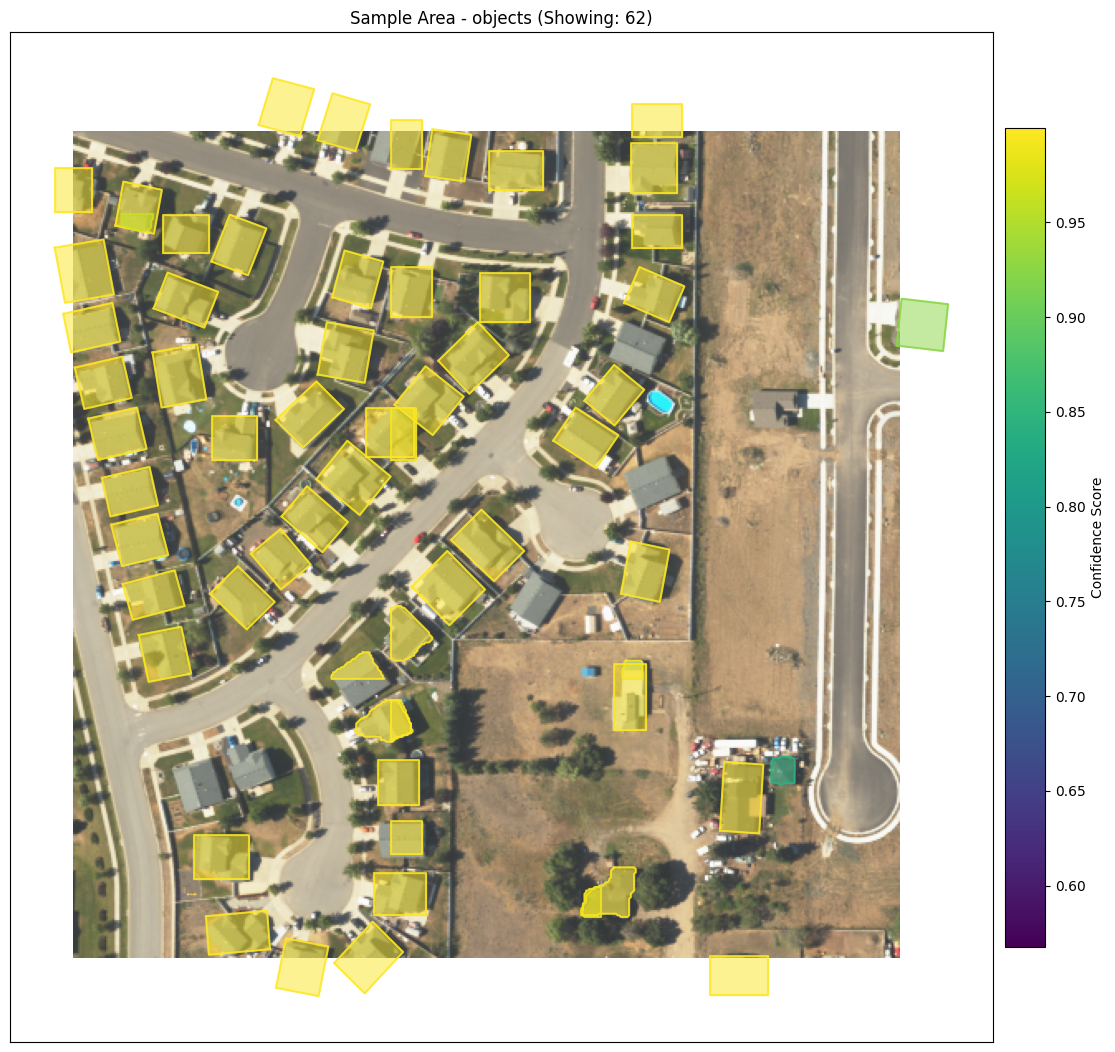

In [18]:
extractor.visualize_results(
    raster_path, gdf_regularized, output_path="naip_buildings_regularized.png"
)

# Apply the workflow to a new dataset

In [1]:
# import os
# import glob
# from tqdm.auto import tqdm

# # Define the input and output directories
# input_dir = "/media/gisense/xihan/250812_tamu_cybertraining_team4/data/interim/chips_600m"
# output_dir = "/media/gisense/xihan/250812_tamu_cybertraining_team4/data/interim/Building_Segmentation/GeoAI_QuishengWu_ESRI"

# # Find all the pre.tif files
# search_pattern = os.path.join(input_dir, "**/pre/*.tif")
# tif_files = glob.glob(search_pattern, recursive=True)

# # Initialize the building footprint extractor if not already done
# # Assuming 'extractor' is already created and model is loaded from previous cells.
# # If not, you would initialize it here:
# # model_path = "building_footprints_usa.pth"
# # extractor = geoai.BuildingFootprintExtractor(model_path=model_path)

# # Process each tif file
# for tif_path in tqdm(tif_files, desc="Processing files"):
    
#     # Get the cell number and pre/post part from the path
#     parts = tif_path.split(os.sep)
#     cell_folder_name = parts[-3] # e.g., cell_00046
#     pre_folder_name = parts[-2] # e.g., pre
    
#     # Create the output directory
#     output_cell_dir = os.path.join(output_dir, f"{cell_folder_name}_{pre_folder_name}")
#     os.makedirs(output_cell_dir, exist_ok=True)
    
#     # Define the output file path
#     base_filename = os.path.basename(tif_path).replace('.tif', '')
#     output_geojson_path = os.path.join(output_cell_dir, f"{base_filename}.geojson")
    
#     # Extract building footprints as vector
#     gdf = extractor.process_raster(
#         tif_path,
#         output_path=output_geojson_path, # Temporarily save here, will be overwritten by regularized version
#         batch_size=4,
#         confidence_threshold=0.5,
#         overlap=0.25,
#         nms_iou_threshold=0.5,
#         min_object_area=100,
#         max_object_area=None,
#         mask_threshold=0.5,
#         simplify_tolerance=1.0,
#     )

#     # Regularize building footprints
#     if gdf is not None and not gdf.empty:
#         gdf_regularized = extractor.regularize_buildings(
#             gdf=gdf,
#             min_area=100,
#             angle_threshold=15,
#             orthogonality_threshold=0.3,
#             rectangularity_threshold=0.7,
#         )
        
#         # Save the regularized footprints
#         gdf_regularized.to_file(output_geojson_path, driver='GeoJSON')
        
#         # Generate and save visualization
#         output_png_path = os.path.join(output_cell_dir, f"{base_filename}_visualization.png")
#         extractor.visualize_results(
#             tif_path, 
#             gdf_regularized, 
#             output_path=output_png_path
#         )

# print("All files processed.")